In [3]:
# --- Loading Data using kagglehub ---
# This cell automatically detects the downloaded CSV file and loads it into a DataFrame.

import kagglehub
import pandas as pd
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("atharvasoundankar/global-housing-market-analysis-2015-2024")
print("Path to dataset files:", path)

# List files in the directory to find the CSV name
files = os.listdir(path)
print("Files found:", files)

# Find the first CSV file in the directory
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# Load the dataset
df_housing = pd.read_csv(full_path)

# Quick check of the data
print(f"\nSuccessfully loaded: {csv_file}")
display(df_housing.head())


100%|██████████| 17.9k/17.9k [00:00<00:00, 10.8MB/s]

Extracting files...
Path to dataset files: C:\Users\Emails and Social\.cache\kagglehub\datasets\atharvasoundankar\global-housing-market-analysis-2015-2024\versions\1
Files found: ['global_housing_market_extended.csv']



Successfully loaded: global_housing_market_extended.csv


,Country,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
0,USA,2015,117.454012,116.550001,9.587945,4.493292,1.514121,-0.752044,-0.796707,85.985284,118.089201
1,USA,2016,150.807258,51.440915,11.729189,5.662213,1.880204,-0.545400,-0.358084,69.127267,111.980515
2,USA,2017,123.194502,70.386040,8.506676,2.197469,2.398940,0.930895,0.596245,83.555279,85.973903
3,USA,2018,131.423444,91.469020,3.418054,4.537724,1.608407,-1.479587,2.321099,88.968961,134.671788
4,USA,2019,110.461377,56.837048,9.158097,3.700762,1.293249,1.961415,-0.879640,87.279612,90.702399


In [4]:
# --- Basic Exploratory Data Analysis (EDA) ---
# This cell provides summary statistics and checks for data integrity.

# 1. Check the dimensions of the dataset
print(f"Dataset shape: {df_housing.shape}")

# 2. Get summary statistics for numerical columns
# This helps identify the scale and potential outliers in prices and rates.
print("\n--- Summary Statistics ---")
display(df_housing.describe())

# 3. Check for missing values (crucial for Data Cleaning)
print("\n--- Missing Values ---")
print(df_housing.isnull().sum())

# 4. Check unique countries to understand the scope
unique_countries = df_housing['Country'].unique()
print(f"\nNumber of unique countries: {len(unique_countries)}")
print(f"Countries included: {', '.join(unique_countries)}")

# 5. Check the time range
year_min = df_housing['Year'].min()
year_max = df_housing['Year'].max()
print(f"\nAnalysis Period: {year_min} - {year_max}")


Dataset shape: (200, 11)

--- Summary Statistics ---


,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2019.500000,130.381022,83.048370,7.237768,4.150621,3.649756,2.133722,0.722806,74.769891,111.204257
std,2.879489,28.752229,21.439858,2.576085,1.380222,1.881938,2.413270,1.035691,8.734246,24.309473
min,2015.000000,80.552212,50.354311,3.041688,1.537814,0.532110,-1.921833,-0.961391,60.172760,70.968678
25%,2017.000000,104.142562,60.466671,5.034207,3.045278,1.939199,-0.095628,-0.183320,66.923842,90.182198
50%,2019.500000,129.193653,83.721711,7.375697,4.329643,3.664625,2.307548,0.722372,75.100060,110.593807
75%,2022.000000,157.127098,100.604665,9.276196,5.217706,5.261720,4.272776,1.621317,82.677430,133.780445
max,2024.000000,179.971767,119.855388,11.879671,6.485623,6.912349,5.958931,2.497948,89.788944,149.735748



--- Missing Values ---
Country                  0
Year                     0
House Price Index        0
Rent Index               0
Affordability Ratio      0
Mortgage Rate (%)        0
Inflation Rate (%)       0
GDP Growth (%)           0
Population Growth (%)    0
Urbanization Rate (%)    0
Construction Index       0
dtype: int64

Number of unique countries: 20
Countries included: USA, Canada, UK, Germany, France, Italy, Spain, Australia, India, China, Japan, Brazil, South Korea, Mexico, South Africa, Russia, Netherlands, Sweden, Switzerland, UAE

Analysis Period: 2015 - 2024


## Exploratory Data Analysis (EDA)
In this section, we analyze the distribution of the **House Price Index** and examine how the housing market varies across different countries. 

Key objectives:
1.  Visualize the distribution of house prices.
2.  Identify the Top 10 countries with the highest average House Price Index.
3.  Check for potential outliers in the economic indicators.


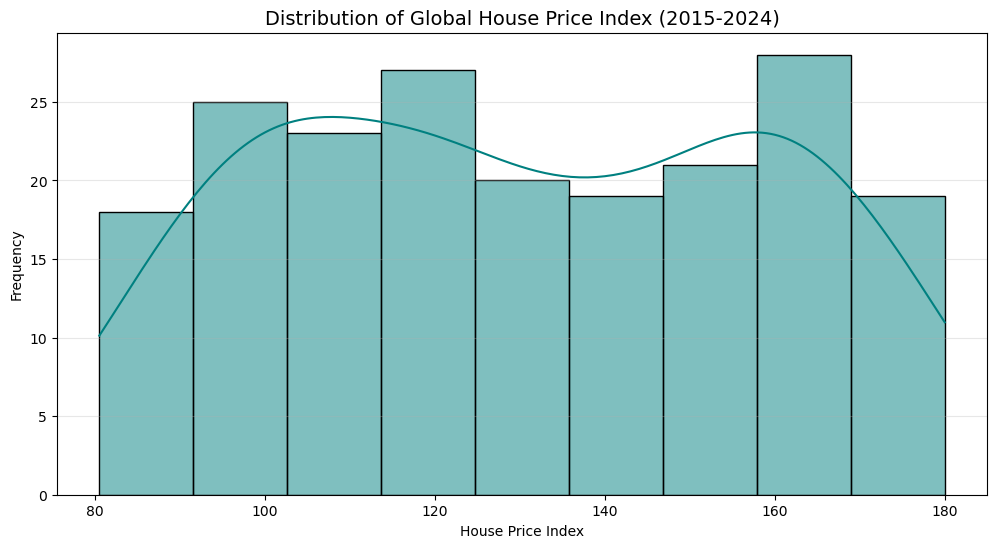

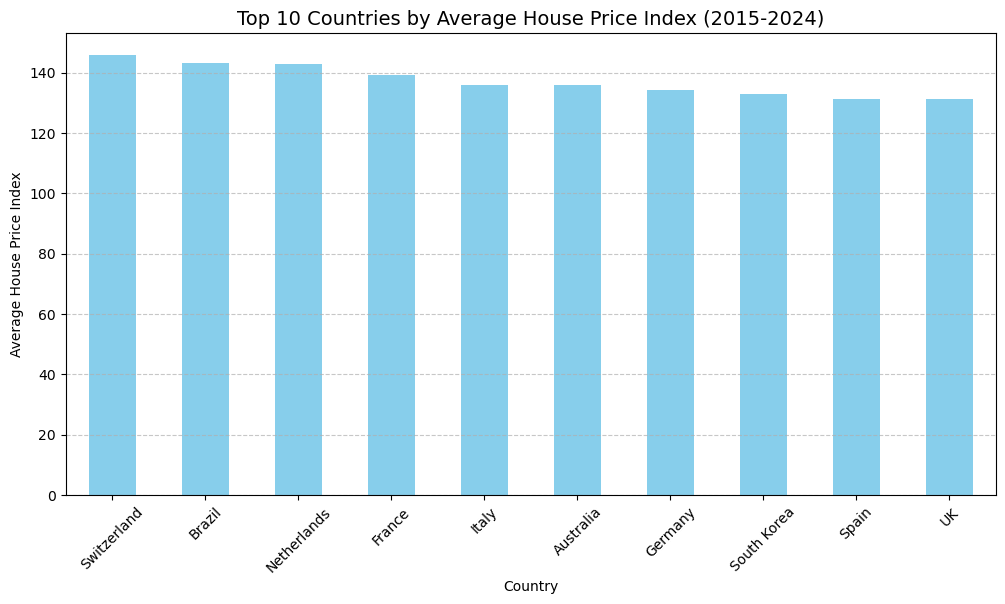

Descriptive Statistics for Top 10 Countries:
Country
Switzerland    145.830268
Brazil         143.080085
Netherlands    142.847068
France         139.344904
Italy          135.926407
Australia      135.752524
Germany        134.204203
South Korea    132.735159
Spain          131.289414
UK             131.094884
Name: House Price Index, dtype: float64


In [6]:
# --- Exploratory Data Analysis: Distributions and Rankings ---

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution of House Price Index
plt.figure(figsize=(12, 6))
sns.histplot(df_housing['House Price Index'], kde=True, color='teal')
plt.title('Distribution of Global House Price Index (2015-2024)', fontsize=14)
plt.xlabel('House Price Index')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Identifying Top 10 Countries by Average House Price Index
top_countries = df_housing.groupby('Country')['House Price Index'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Average House Price Index (2015-2024)', fontsize=14)
plt.ylabel('Average House Price Index')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Descriptive Statistics for the Top 10
print("Descriptive Statistics for Top 10 Countries:")
print(top_countries)


## Time Series Analysis: Comparative Trends
In this section, we compare the **House Price Index** trends of specific influential economies. 
By plotting multiple countries on the same graph, we can observe how global events (like the 2020-2021 period) affected different markets simultaneously.
We will also examine the relationship between **GDP Growth** and **House Price Index** to see if economic expansion directly correlates with housing inflation.


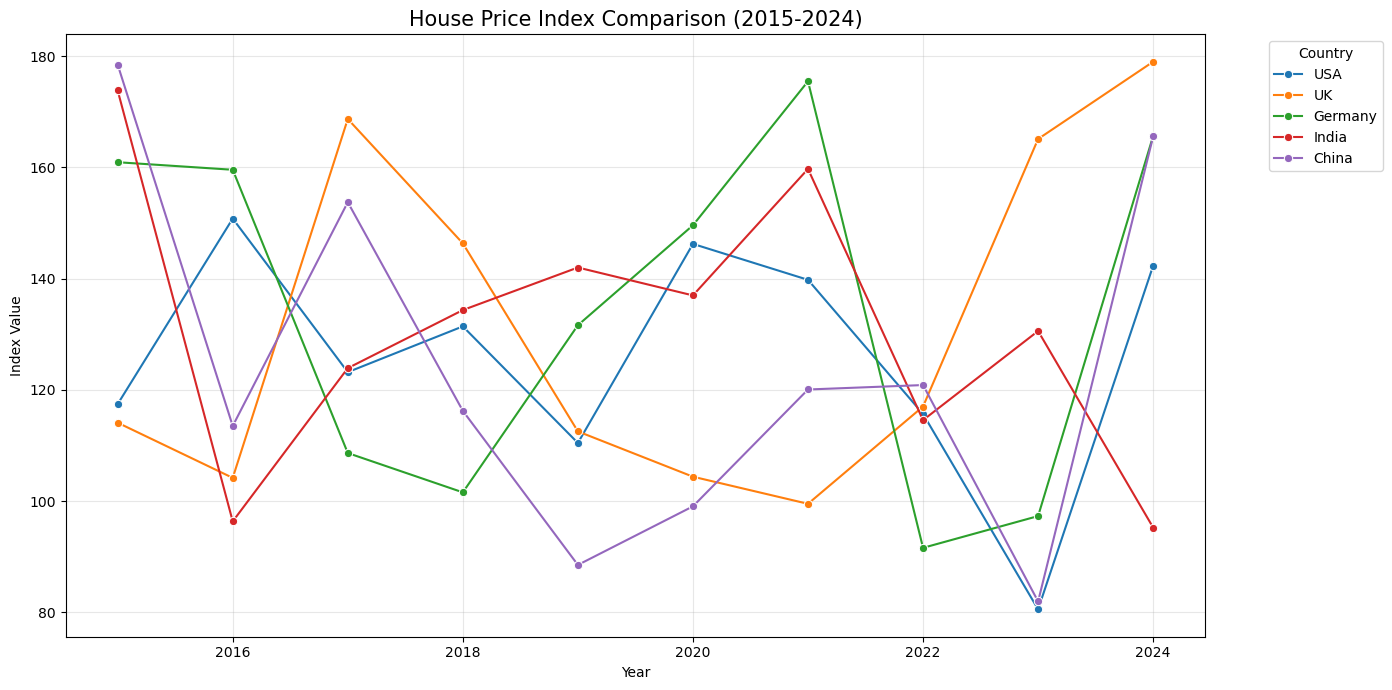

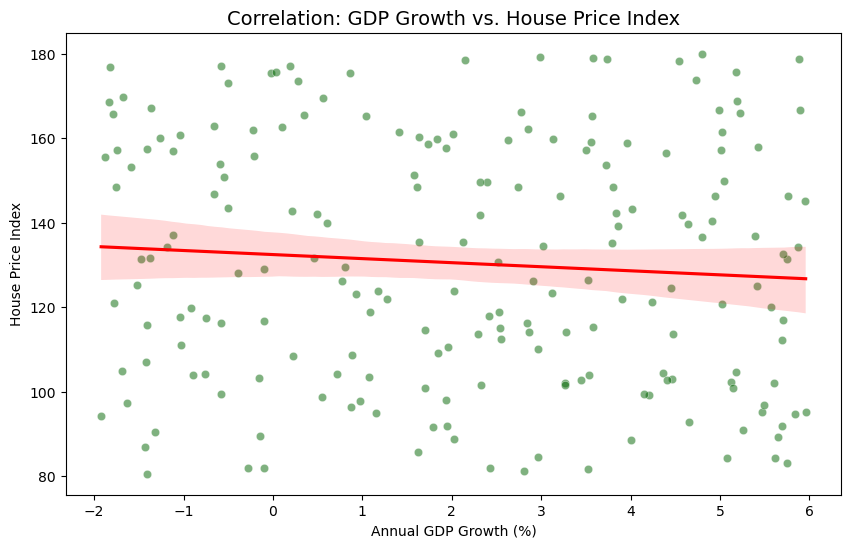

Year-over-Year Growth calculated. Preview of new feature:


,Country,Year,House Price Index,Price_Growth_YoY
1,USA,2016,150.807258,28.396855
2,USA,2017,123.194502,-18.309965
3,USA,2018,131.423444,6.679634
4,USA,2019,110.461377,-15.950021
5,USA,2020,146.252228,32.401236


In [7]:
# --- Comparative Trends and Economic Correlation ---

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compare specific countries (e.g., USA, Germany, UK, China, India)
selected_countries = ['USA', 'Germany', 'UK', 'China', 'India']
df_filtered = df_housing[df_housing['Country'].isin(selected_countries)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_filtered, x='Year', y='House Price Index', hue='Country', marker='o')
plt.title('House Price Index Comparison (2015-2024)', fontsize=15)
plt.ylabel('Index Value')
plt.grid(True, alpha=0.3)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Relationship between GDP Growth and Housing Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_housing, x='GDP Growth (%)', y='House Price Index', alpha=0.5, color='darkgreen')
sns.regplot(data=df_housing, x='GDP Growth (%)', y='House Price Index', scatter=False, color='red')
plt.title('Correlation: GDP Growth vs. House Price Index', fontsize=14)
plt.xlabel('Annual GDP Growth (%)')
plt.ylabel('House Price Index')
plt.show()

# 3. Calculating annual growth rates (Feature Engineering)
# We calculate the percentage change in prices year-over-year for each country
df_housing['Price_Growth_YoY'] = df_housing.groupby('Country')['House Price Index'].pct_change() * 100

print("Year-over-Year Growth calculated. Preview of new feature:")
display(df_housing[['Country', 'Year', 'House Price Index', 'Price_Growth_YoY']].dropna().head())


## Integrating the Second Data Source: Financial Market Data
To comply with the project requirements, we are introducing a second independent data source. 
We will use the `yfinance` library to fetch historical data for the **S&P 500 Index (^GSPC)**. 

The goal is to:
1.  Retrieve annual stock market performance from 2015 to 2024.
2.  Merge this data with our housing dataset.
3.  Analyze the correlation between equity markets and housing market trends.


In [10]:
# --- Corrected Fetching Second Data Source: S&P 500 Index ---

import yfinance as yf
import pandas as pd

# 1. Download S&P 500 historical data
print("Fetching S&P 500 data...")
sp500 = yf.download("^GSPC", start="2015-01-01", end="2024-12-31", interval="1d")

# 2. Fix for MultiIndex columns (Common in new yfinance versions)
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

# 3. Resample to annual data (last trading day of each year)
sp500_annual = sp500['Close'].resample('YE').last().reset_index()
sp500_annual['Year'] = sp500_annual['Date'].dt.year

# 4. Rename and Calculate Returns
sp500_annual.rename(columns={'Close': 'SP500_Close'}, inplace=True)
sp500_annual['SP500_Return_Pct'] = sp500_annual['SP500_Close'].pct_change() * 100

# 5. Merging with the Housing Dataset
# Note: Ensure df_housing is defined in your previous cells
df_combined = pd.merge(df_housing, sp500_annual[['Year', 'SP500_Close', 'SP500_Return_Pct']], on='Year', how='left')

print("Data merging complete.")
display(df_combined[['Country', 'Year', 'House Price Index', 'SP500_Close', 'SP500_Return_Pct']].dropna().head())


[*********************100%***********************]  1 of 1 completed

Fetching S&P 500 data...
Data merging complete.


,Country,Year,House Price Index,SP500_Close,SP500_Return_Pct
1,USA,2016,150.807258,2238.830078,9.535023
2,USA,2017,123.194502,2673.610107,19.419966
3,USA,2018,131.423444,2506.850098,-6.237260
4,USA,2019,110.461377,3230.780029,28.878070
5,USA,2020,146.252228,3756.070068,16.258923


## Comparative Analysis: Real Estate vs. Stock Market
With the datasets merged, we can now visualize how the global housing market correlates with the stock market. 
This helps determine if real estate acts as a hedge or if it moves in tandem with equity markets.


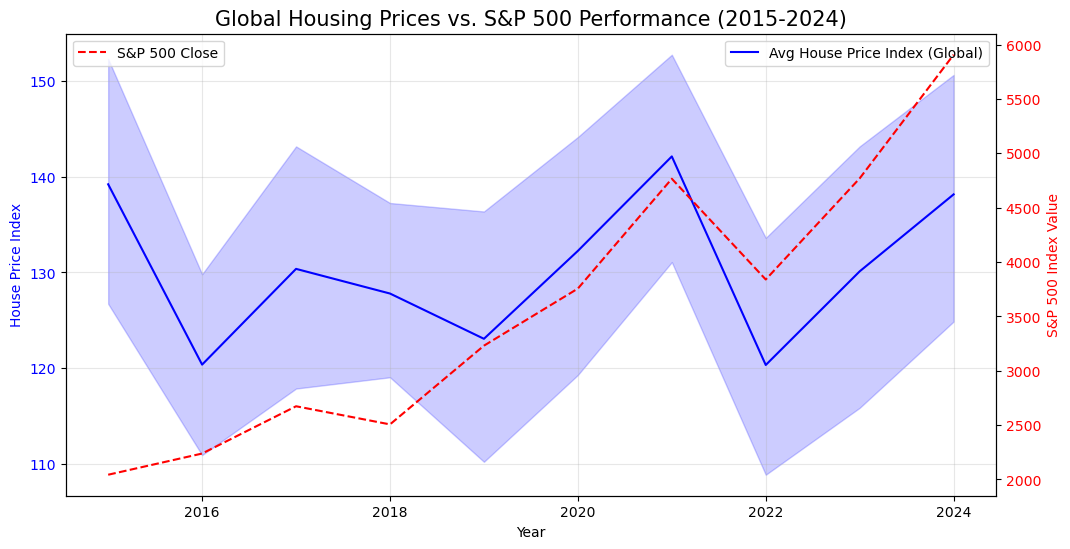

In [11]:
# --- Visualization: Housing vs. Stock Market Trends ---

import matplotlib.pyplot as plt

# Comparison of Global Average House Price Index vs S&P 500
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Housing
sns.lineplot(data=df_combined, x='Year', y='House Price Index', ax=ax1, color='blue', label='Avg House Price Index (Global)')
ax1.set_ylabel('House Price Index', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary Axis: S&P 500
ax2 = ax1.twinx()
sns.lineplot(data=sp500_annual, x='Year', y='SP500_Close', ax=ax2, color='red', label='S&P 500 Close', linestyle='--')
ax2.set_ylabel('S&P 500 Index Value', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Global Housing Prices vs. S&P 500 Performance (2015-2024)', fontsize=15)
ax1.grid(True, alpha=0.3)
plt.show()


## Statistical Analysis: Hypothesis Testing
In this section, we apply Data Science principles to test a specific economic hypothesis.

**Null Hypothesis ($H_0$):** There is no significant relationship between Mortgage Rates and the House Price Index.
**Alternative Hypothesis ($H_a$):** Mortgage Rates have a significant impact on the House Price Index.

We will use a **Simple Linear Regression** model to determine the p-value and the coefficient of determination ($R^2$). This helps us understand how much of the variance in house prices can be explained by interest rates.


                            OLS Regression Results                            
Dep. Variable:      House Price Index   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9677
Date:                Sat, 18 Apr 2026   Prob (F-statistic):              0.326
Time:                        20:25:58   Log-Likelihood:                -954.54
No. Observations:                 200   AIC:                             1913.
Df Residuals:                     198   BIC:                             1920.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               124.3510      6.45

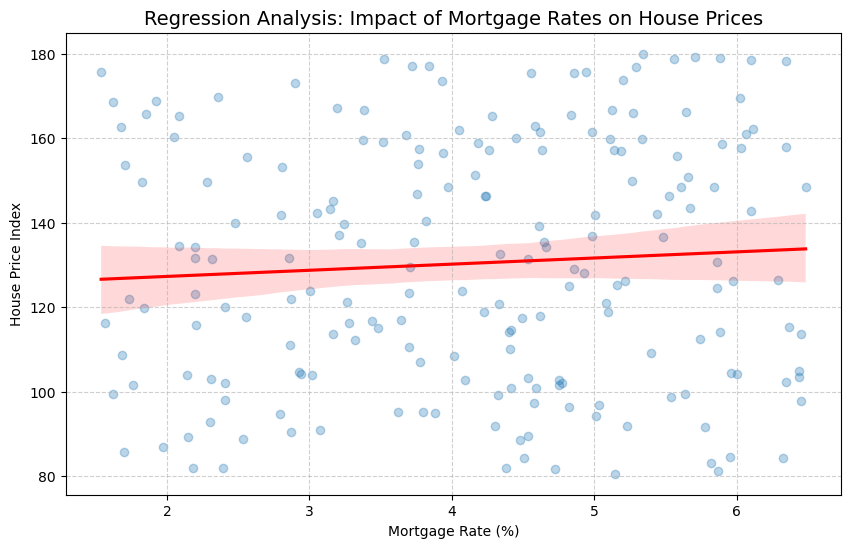

In [12]:
# --- Statistical Modeling: Linear Regression ---

import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data
# We drop NaNs and define our Independent Variable (X) and Dependent Variable (y)
df_stats = df_combined[['Mortgage Rate (%)', 'House Price Index']].dropna()

X = df_stats['Mortgage Rate (%)']
y = df_stats['House Price Index']

# 2. Add a constant (intercept) to the model
X = sm.add_constant(X)

# 3. Fit the OLS (Ordinary Least Squares) model
model = sm.OLS(y, X).fit()

# 4. Print the Statistical Summary
print(model.summary())

# 5. Visualize the Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(data=df_stats, x='Mortgage Rate (%)', y='House Price Index', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Regression Analysis: Impact of Mortgage Rates on House Prices', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Advanced Predictive Modeling: Random Forest Regressor
To capture complex, non-linear relationships in the global housing market, we implement a **Random Forest Regressor**. 
Unlike simple linear models, Random Forest uses an ensemble of decision trees to provide more robust predictions and can handle interactions between multiple economic indicators.

**Goals:**
1. Train a model to predict the **House Price Index**.
2. Evaluate model performance using **Mean Absolute Error (MAE)** and **R-squared ($R^2$)**.
3. Identify **Feature Importance** to see which global economic factors drive the market the most.


Model Performance:
Mean Absolute Error (MAE): 21.70
R-squared Score (R2): 0.01


C:\Users\Emails and Social\AppData\Local\Temp\ipykernel_5148\2678872193.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


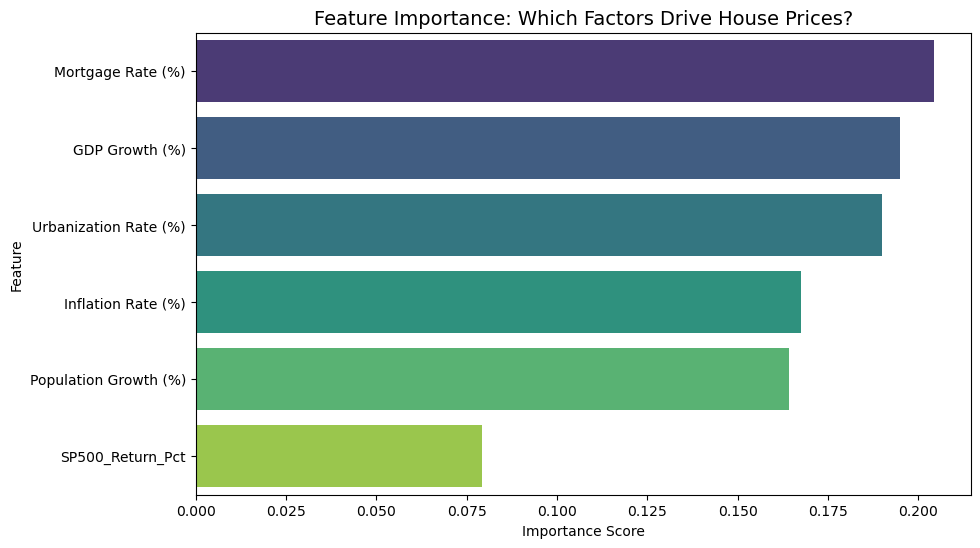

In [14]:
# --- Advanced Machine Learning: Random Forest and Feature Importance ---

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# 1. Prepare features (X) and target (y)
# We select key economic indicators and the newly added S&P 500 data
features = ['Mortgage Rate (%)', 'Inflation Rate (%)', 'GDP Growth (%)', 
            'Population Growth (%)', 'Urbanization Rate (%)', 'SP500_Return_Pct']

# Drop rows with missing values in these specific columns for training
df_ml = df_combined.dropna(subset=features + ['House Price Index'])

X = df_ml[features]
y = df_ml['House Price Index']

# 2. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make predictions and evaluate
y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared Score (R2): {r2:.2f}")

# 5. Feature Importance Visualization
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance: Which Factors Drive House Prices?', fontsize=14)
plt.xlabel('Importance Score')
plt.show()
